# Purpose: get training working for block-diagonal matrices

In [3]:
import os
from collections import defaultdict
import pickle

import numpy as np

import torch
import blobfile as bf
import transformer_lens
from huggingface_hub import hf_hub_download
# from sae_lens import SparseAutoencoderDictionary
import sparse_autoencoder

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from structured_sae.operations import (
    low_rank_mmm,
    kronecker_mmm,
    sum_kronecker_mmm,
    block_diagonal_mmm,
)

In [4]:
!nvidia-smi

Sun Aug 11 20:48:01 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:84:00.0 Off |                    0 |
| N/A   41C    P0             52W /  300W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
# compute prime factorization
def prime_factors(n):
    """Returns list of prime factors of n.
    >>> prime_factors(10)
    [2, 5]
    >>> prime_factors(32)
    [2, 2, 2, 2, 2]
    """
    i = 2
    factors = []
    while i * i <= n:
        if n % i:
            i += 1
        else:
            n //= i
            factors.append(i)
    if n > 1:
        factors.append(n)
    return factors

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
torch.set_default_dtype(dtype)

In [7]:
layer_index = 7
location = "resid_post_mlp"

In [8]:
with bf.BlobFile(sparse_autoencoder.paths.v5_32k(location, layer_index), mode="rb") as f:
    state_dict = torch.load(f)
    autoencoder = sparse_autoencoder.Autoencoder.from_state_dict(state_dict)
    autoencoder.to(device)

In [9]:
W_e = autoencoder.encoder.weight.detach()
W_d = autoencoder.decoder.weight.detach()

In [10]:
for i, d in enumerate(W_e.shape):
    print(f"W_e dim {i} size {d:7d}:  {prime_factors(d)}")
for i, d in enumerate(W_d.shape):
    print(f"W_d dim {i} size {d:7d}:  {prime_factors(d)}")

W_e dim 0 size   32768:  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
W_e dim 1 size     768:  [2, 2, 2, 2, 2, 2, 2, 2, 3]
W_d dim 0 size     768:  [2, 2, 2, 2, 2, 2, 2, 2, 3]
W_d dim 1 size   32768:  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


### Block diagonal approximation

In [12]:
block_diagonal_encoder_dynamics = defaultdict(list)
block_diagonal_encoder_parameters = dict()

n_blocks = [128, 64, 32, 16, 8, 4, 2] # must be a divisor of both 32768 and 768
steps = 3_000

for b in tqdm(n_blocks):
    var_W_e = W_e.var().item()
    n, m = W_e.shape # n = 32768, m = 768

    # initialize V
    # V = torch.randn(m, m, device=device, dtype=dtype)
    V = torch.eye(m, device=device, dtype=dtype)
    # initialize W_blocks
    W_blocks = torch.randn(b, n // b, m // b, device=device, dtype=dtype)
    
    # set the variances appropriately
    # first let's imagine that we multiply by V which has variance
    # s_v^2. Then each term in the resulting block-sparse matrix
    # times V is a sum of m // n_blocks Gaussians with variance
    # s_b^2. So the variance of each element in the product
    # has variance (m // n_blocks) * s_b^2 * s_v^2. We have:
    # var_W_e = (m // n_blocks) * s_b^2 * s_v^2. For now, let's
    # set the variance of the two matrices to be equal, so
    # s = s_b = s_v. Then var_W_e = (m // n_blocks) * s^4.
    # So s = (var_W_e / (m // n_blocks))^(1/4).
    s = (var_W_e / (m // b)) ** 0.25
    V *= s
    W_blocks *= s
    V.requires_grad = True
    W_blocks.requires_grad = True

    block_diagonal_encoder_parameters[b] = W_blocks.numel() + V.numel()

    # gradient descent to optimize W1, W2
    optimizer = torch.optim.Adam([W_blocks, V], lr=1e-3)
    for i in range(steps):
        W_e_approx = block_diagonal_mmm(W_blocks) @ V
        loss = 0.5 * torch.log(1.0 + (W_e - W_e_approx).square()).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        block_diagonal_encoder_dynamics[b].append(loss.item())


  0%|          | 0/7 [00:00<?, ?it/s]

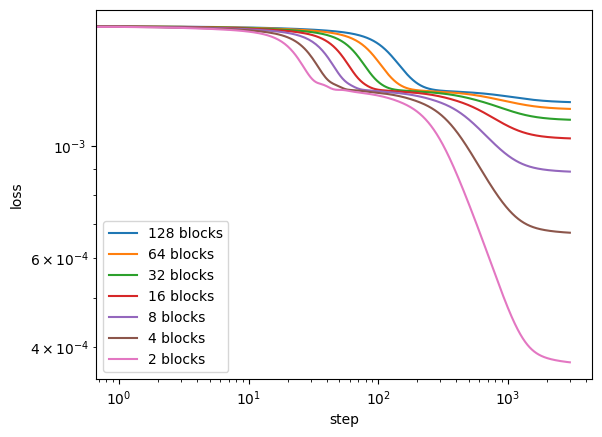

In [13]:
for b in n_blocks:
    plt.plot(list(range(len(block_diagonal_encoder_dynamics[b]))), block_diagonal_encoder_dynamics[b], label=f"{b} blocks")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('step')
plt.ylabel('loss')
plt.legend()

In [14]:
# also compute SVD of W_e and use that for the low-rank approximation frontier
U, S, V = torch.linalg.svd(W_e, full_matrices=False)
svd_ranks = list(range(4, 768, 4))

# compute loss on various ranks of the SVD
svd_losses = []
svd_parameters = []
for rank in tqdm(svd_ranks):
    U_r = U[:, :rank]
    S_r = S[:rank]
    V_r = V[:rank, :]
    W_e_approx = U_r @ torch.diag(S_r) @ V_r
    loss = 0.5 * torch.log(1.0 + (W_e - W_e_approx).square()).mean()
    svd_losses.append(loss.item())
    svd_parameters.append(U_r.numel() + S_r.numel() + V_r.numel())

  0%|          | 0/191 [00:00<?, ?it/s]

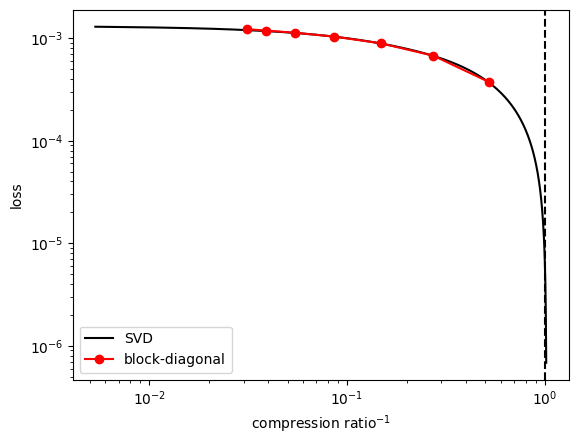

In [19]:
svd_ratios = [p / W_e.numel() for p in svd_parameters]
plt.plot(svd_ratios, svd_losses, label='SVD', color='black')

block_diagonal_ratios = [block_diagonal_encoder_parameters[b] / W_e.numel() for b in n_blocks]
block_diagonal_losses = [min(block_diagonal_encoder_dynamics[b]) for b in n_blocks]
plt.plot(block_diagonal_ratios, block_diagonal_losses, 'o-', label='block-diagonal', color='red')

plt.axvline(x=1, color='k', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\text{compression ratio}^{-1}$')
plt.ylabel('loss')
plt.legend()